In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

df = pd.read_excel('Sample - Superstore.xlsx')
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [ ]:
snapshot_date = df['Order Date'].max() + pd.DateOffset(days=1)
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days,#14-06  13-06  #1
    'Order ID': 'nunique',#
    'Sales': 'sum'
}).rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
})

In [ ]:
rfm
#2025
#AA-10315: recency:185
#09/jan , 05   #5563.560


,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156
...,...,...,...
XP-21865,44,11,2374.658
YC-21895,5,5,5454.350
YS-21880,10,8,6720.444


In [ ]:
# Quintile-based scoring (1=Lowest, 5=Highest)
#recency:416            1
#793 -->
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=range(5,0,-1))#lowest:1:416  5:1
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 5, labels=range(1,6))
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=range(1,6))

# Composite RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


In [ ]:
rfm
#rfm:225
#best r_score:5
#best
#frequency

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,aov,CLV,CLV_Segment
Customer ID,,,,,,,,,,,
AA-10315,185,5,5563.560,2,2,5,225,225,1112.712000,84.190063,Platinum
AA-10375,20,9,1056.390,5,5,2,552,552,117.376667,15.985725,Bronze
AA-10480,260,4,1790.512,1,1,3,113,At-Risk Customers,447.628000,27.094759,Silver
AA-10645,56,6,5086.935,3,3,5,335,Loyal Customers,847.822500,76.977579,Platinum
AB-10015,416,3,886.156,1,1,1,111,At-Risk Customers,295.385333,13.409675,Bronze
...,...,...,...,...,...,...,...,...,...,...,...
XP-21865,44,11,2374.658,4,5,3,453,Loyal Customers,215.878000,35.934295,Gold
YC-21895,5,5,5454.350,5,2,5,525,525,1090.870000,82.537453,Platinum
YS-21880,10,8,6720.444,5,4,5,545,Champions,840.055500,101.696504,Platinum


In [ ]:

segmentation_map = {
    r'^[4-5][4-5][4-5]$': 'Champions',#555  554 545
    r'^[3-5][3-5][3-5]$': 'Loyal Customers',
    r'^[2-4][2-4][2-4]$': 'Potential Loyalists',
    r'^[1-3][1-3][1-3]$': 'At-Risk Customers'
}


rfm['Segment'] = rfm['RFM_Score'].replace(segmentation_map, regex=True)








In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
At-Risk Customers,206
Loyal Customers,179
Potential Loyalists,112
Champions,85
511,15
235,11
532,11
411,10
254,9


In [ ]:
#Challenges:
#As of we can see that while we are calculating the rfm score ,  segmentation of 211 customers cant be obtained always as per the standards
#hence lets segment them using clv
#clv=customer lifetime value

#500 , frequ:10        recently:ordered


#clv:aov->total sales/freq
#freq
#lifetime span

#clv=aov*freq*lifetime span
#clv=500*10*12
#60000--> total amount that

#aov-250
#5
#12

#clv=250*5*12
#1250*12
#1750



In [ ]:
customer_sales = df.groupby('Customer ID')['Sales'].sum()
customer_orders = df.groupby('Customer ID')['Order ID'].nunique()
aov = customer_sales / customer_orders
rfm['aov']=aov
# Step 2: Calculate Frequency (orders per customer / total unique customers)
total_customers = df['Customer ID'].nunique()
frequency = customer_orders / total_customers

# Step 3: Define expected Customer Lifespan
lifespan = 12  # in months

# Step 4: Compute CLV
clv = aov * frequency * lifespan
rfm['CLV']=clv

rfm

#rfm:past history
#clv:predictive
#360 view
#clv and rfm

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,aov,CLV
Customer ID,,,,,,,,,,
AA-10315,185,5,5563.560,2,2,5,225,225,1112.712000,84.190063
AA-10375,20,9,1056.390,5,5,2,552,552,117.376667,15.985725
AA-10480,260,4,1790.512,1,1,3,113,At-Risk Customers,447.628000,27.094759
AA-10645,56,6,5086.935,3,3,5,335,Loyal Customers,847.822500,76.977579
AB-10015,416,3,886.156,1,1,1,111,At-Risk Customers,295.385333,13.409675
...,...,...,...,...,...,...,...,...,...,...
XP-21865,44,11,2374.658,4,5,3,453,Loyal Customers,215.878000,35.934295
YC-21895,5,5,5454.350,5,2,5,525,525,1090.870000,82.537453
YS-21880,10,8,6720.444,5,4,5,545,Champions,840.055500,101.696504


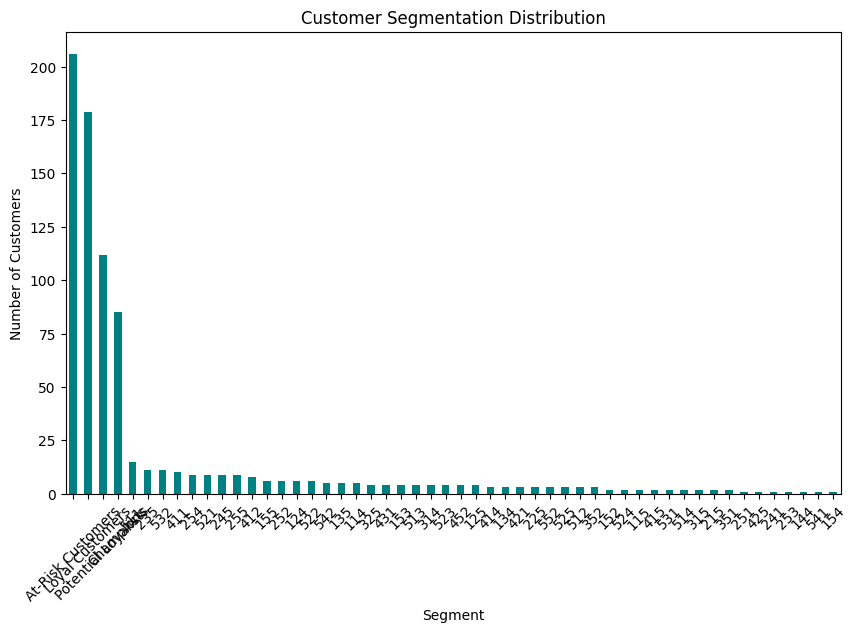

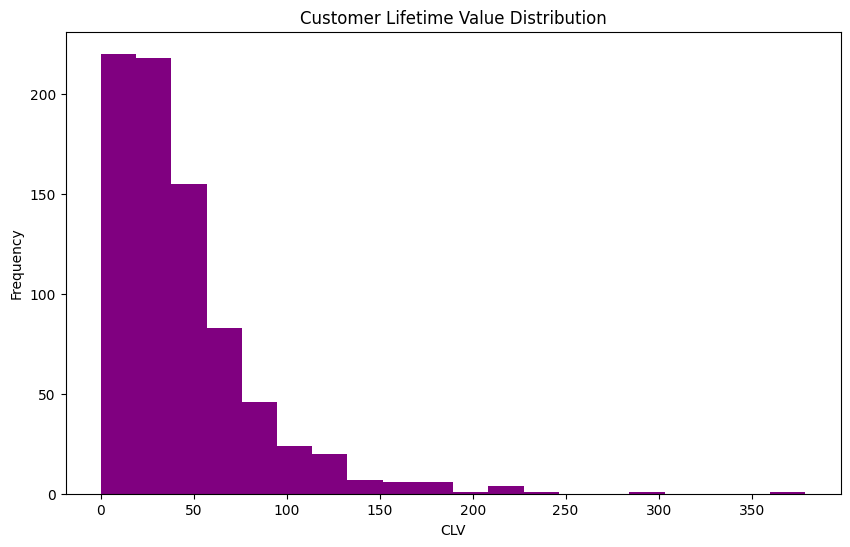

In [ ]:
# RFM Segments
plt.figure(figsize=(10,6))
rfm['Segment'].value_counts().plot(kind='bar', color='teal')
plt.title('Customer Segmentation Distribution')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

# CLV Distribution
plt.figure(figsize=(10,6))
rfm['CLV'].plot(kind='hist', bins=20, color='purple')
plt.title('Customer Lifetime Value Distribution')
plt.xlabel('CLV')
plt.show()

#Key Insights
 1) Champions (10.2%)
 High RFM + Avg CLV ₹80.8 → Ideal for upselling & loyalty rewards
 2) At-Risk (16.7%)
 Previously active, now dormant → Target for reactivation campaigns
 3) Loyal (1.8%)
 Medium RFM + Avg CLV ₹34.3 → Cross-sell to increase value

 CLV Stats
Mean: ₹43.8  Median: ₹34.1


75th Percentile: ₹57.3  Max: ₹378.9

In [ ]:
top_customers = rfm.sort_values('CLV', ascending=False).head(10)
print("High-Value Customers:")
print(top_customers[['CLV', 'Segment']])

High-Value Customers:
                    CLV          Segment
Customer ID                             
SM-20320     378.961665              325
TC-20980     288.305947              125
RB-19360     228.761750  Loyal Customers
TA-21385     220.866885              315
AB-10105     219.019990        Champions
KL-16645     214.505357        Champions
SC-20095     214.007576              155
HL-15040     194.804005  Loyal Customers
SE-20110     184.758204        Champions
CC-12370     183.542073              425


In [ ]:
top_customers = rfm.sort_values('CLV', ascending=True).head(10)
print("Low-Value Customers:")
print(top_customers[['CLV', 'Segment']])

Low-Value Customers:
                  CLV            Segment
Customer ID                             
TS-21085     0.073135  At-Risk Customers
LD-16855     0.080262  At-Risk Customers
CJ-11875     0.249987  At-Risk Customers
MG-18205     0.253301  At-Risk Customers
RS-19870     0.337876                511
SG-20890     0.725538  At-Risk Customers
RE-19405     0.731803  At-Risk Customers
LB-16735     0.759465                411
AS-10135     0.890088                411
JC-15340     1.078381  At-Risk Customers


In [ ]:
rfm['CLV_Segment'] = pd.qcut(rfm['CLV'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])
rfm['CLV_Segment'].value_counts()


,count
CLV_Segment,
Bronze,199
Silver,198
Gold,198
Platinum,198


In [ ]:
# Merge with original data for deeper analysis
enhanced_df = df.merge(rfm[['CLV', 'Segment','CLV_Segment']], on='Customer ID')

# Save results
enhanced_df.to_csv('superstore_rfm_clv_analysis.csv', index=False)

In [ ]:
enhanced_df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment_x,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,CLV,Segment_y,CLV_Segment
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,25.129378,At-Risk Customers,Gold
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,25.129378,At-Risk Customers,Gold
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,14.693106,522,Silver
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,28.465460,Loyal Customers,Gold
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,28.465460,Loyal Customers,Gold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,85.630527,235,Platinum
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,42.483869,Loyal Customers,Platinum
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,42.483869,Loyal Customers,Platinum
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,42.483869,Loyal Customers,Platinum
